In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4, 3)
plt.rcParams['font.size'] = 8
plt.rcParams["figure.autolayout"] = True # same as tight_layout after every plot

from swifd import SwiModel

In [3]:
# space discretization
nlay = 1
ncol = 41
delx = 50
# time discretization
delt = 2000
nstep = 40
hfini = np.zeros(ncol)
hsini = np.zeros(ncol)
# boundary conditions
hleft = 0
U = 0.4
# aquifer
k = 10 # horizontal hydraulic conductivity, m/d
S = 0.2 # storage coefficient, -
Se = 1e-4 # specific storage coef, m^(-1)
zt = 0 # aquifer top, m
zb = -50 # aquifer bottom, m
rhof = 1000 # freshwater density, kg/m3
rhos = 1025 # saltwater density, kg/m3
# source
Qf = [[0, ncol - 1, U]]
# fixed
fixed = [[0, 0, hleft]]

In [8]:
ml = SwiModel(nlay, ncol, delx, xleftc=0)
ml.tdis(nstep=1, delt=1, hfini=hfini, hsini=hsini)
ml.aquifer(k, S=0, Se=0, zb=zb, zt=zt, rhof=rhof, rhos=rhos) # zero storage means instantaneous steady state
ml.set_source(Qf)
ml.set_fixed(fixed, fixed)
hsteady, zetasteady = ml.simulate_freshonly()

iterations: 7


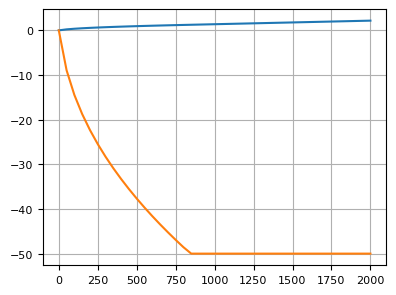

In [9]:
plt.plot(ml.xc, hsteady[1, 0])
plt.plot(ml.xc, zetasteady[1, 0])
plt.grid()

In [46]:
Qf2 = [[0, ncol - 1, U / 2]]
ml2 = SwiModel(nlay, ncol, delx, xleftc=0)
ml2.tdis(nstep=nstep, delt=delt, hfini=hsteady[-1, 0], hsini=hsini)
ml2.aquifer(k, S=S, Se=Se, zb=zb, zt=zt, rhof=rhof, rhos=rhos)
ml2.set_source(Qf2)
ml2.set_fixed(fixed, fixed)
hfsol1, zetasol1 = ml2.simulate_freshonly(silent=True)

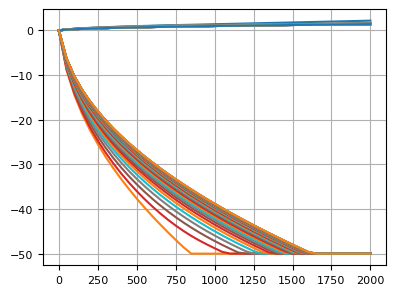

In [47]:
for i in range(nstep + 1):
    plt.plot(ml2.xc, hfsol1[i, 0])
    plt.plot(ml2.xc, zetasol1[i, 0])
plt.grid()

In [48]:
hfsol2, hssol2, zetasol2 = ml2.simulate(silent=True)

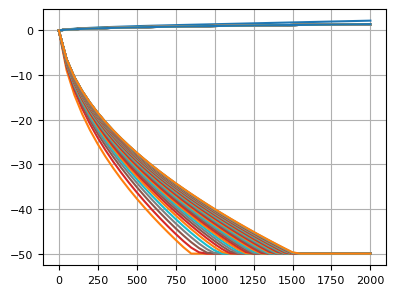

In [56]:
for i in range(nstep + 1):
    plt.plot(ml2.xc, hfsol2[i, 0])
    plt.plot(ml2.xc, zetasol2[i, 0])
plt.grid()

In [50]:
istep = 7
budget = ml2.budget_fresh_step(hfsol2[istep + 1], hfsol2[istep], hssol2[istep + 1], hssol2[istep])
budget

,layer 0,total
Source,4.000000e+02,4.000000e+02
Fixed,-4.932142e+02,-4.932142e+02
GHB,0.000000e+00,0.000000e+00
Drain,0.000000e+00,0.000000e+00
Qtop,0.000000e+00,0.000000e+00
Qbot,0.000000e+00,0.000000e+00
storage_increase,-9.321421e+01,-9.321421e+01
in_min_out,-9.321421e+01,-9.321421e+01
balance,-9.492851e-12,-9.492851e-12


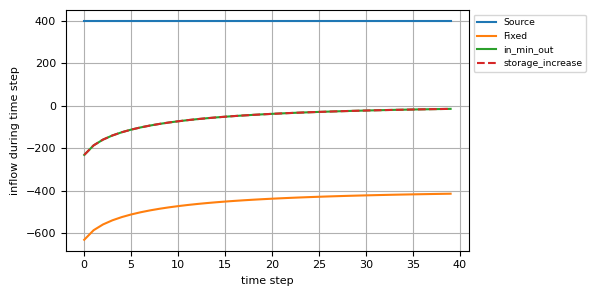

In [51]:
bud = ml2.budget_fresh(hfsol2, hssol2)
bud['layer 0'][['Source', 'Fixed', 'in_min_out', 'storage_increase']].plot(figsize=(6, 3), grid=True, xlabel='time step', 
                    ylabel='inflow during time step', style=3 * ['-'] + ['--']).legend (bbox_to_anchor=(1.0, 1.0), fontsize='small');

In [52]:
istep = 7
budget = ml2.budget_salt_step(hssol2[istep + 1], hssol2[istep], hfsol2[istep + 1], hfsol2[istep])
budget

,layer 0,total
Source,0.000000e+00,0.000000e+00
Fixed,9.321675e+01,9.321675e+01
GHB,0.000000e+00,0.000000e+00
Drain,0.000000e+00,0.000000e+00
Qtop,0.000000e+00,0.000000e+00
Qbot,0.000000e+00,0.000000e+00
storage_increase,9.321675e+01,9.321675e+01
in_min_out,9.321675e+01,9.321675e+01
balance,1.023182e-12,1.023182e-12


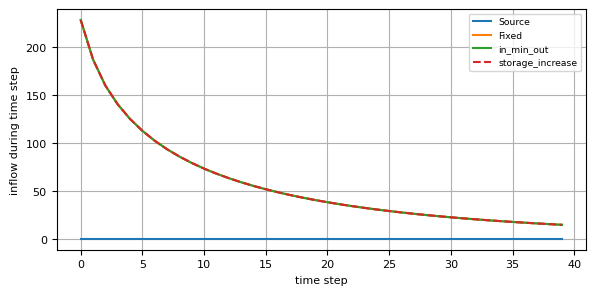

In [53]:
bud = ml2.budget_salt(hfsol2, hssol2)
bud['layer 0'][['Source', 'Fixed', 'in_min_out', 'storage_increase']].plot(figsize=(6, 3), grid=True, xlabel='time step', 
                    ylabel='inflow during time step',  style=3 * ['-'] + ['--']).legend (bbox_to_anchor=(1.0, 1.0), fontsize='small')

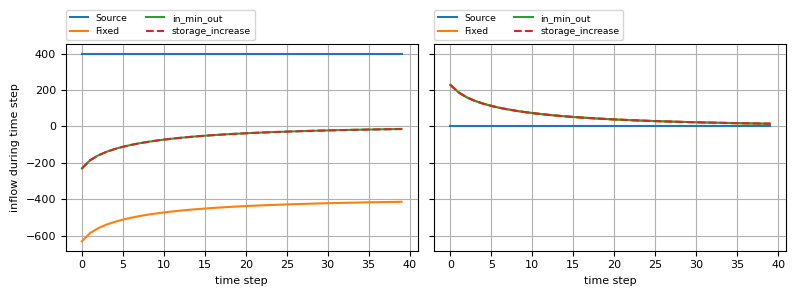

In [54]:
plt.figure(figsize=(8, 3))
ax1 = plt.subplot(121)
bud = ml2.budget_fresh(hfsol2, hssol2)
bud['layer 0'][['Source', 'Fixed', 'in_min_out', 'storage_increase']].plot(grid=True, xlabel='time step', 
                    ylabel='inflow during time step', ax=ax1, style=3 * ['-'] + ['--']).legend (loc=(0, 1.02), ncol=2, fontsize='small')
#
ax2 = plt.subplot(122, sharey=ax1)
bud = ml2.budget_salt(hfsol2, hssol2)
bud['layer 0'][['Source', 'Fixed', 'in_min_out', 'storage_increase']].plot(grid=True, xlabel='time step', 
                    ylabel='inflow during time step', ax=ax2, style=3 * ['-'] + ['--']).legend (loc=(0, 1.02), ncol=2, fontsize='small');

In [55]:
Qf3 = [[0, ncol - 1, 2 * U]]
ml3 = SwiModel(nlay, ncol, delx, xleftc=0)
ml3.tdis(nstep=nstep, delt=delt, hfini=hfsol2[-1, 0], hsini=hssol2[-1, 0])
ml3.aquifer(k, S=S, Se=Se, zb=zb, zt=zt, rhof=rhof, rhos=rhos)
ml3.set_source(Qf3)
ml3.set_fixed(fixed, fixed)
hfsol3, zetasol3 = ml3.simulate_freshonly(silent=True)

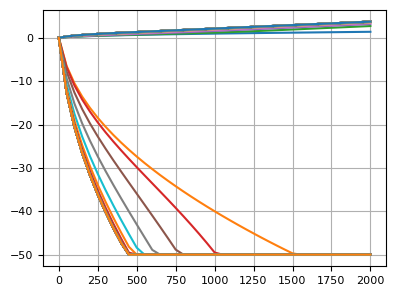

In [57]:
for i in range(nstep + 1):
    plt.plot(ml3.xc, hfsol3[i, 0])
    plt.plot(ml3.xc, zetasol3[i, 0])
plt.grid()